# Fine - tuning LLama3 in GPU A100

## Install

In [ ]:
!pip install transformers datasets accelerate bitsandbytes peft
!pip install sentencepiece

## import

In [ ]:
import pandas as pd
import json
from google.colab import drive
import os

drive.mount('/content/drive')

## Data preparing for QA Medical

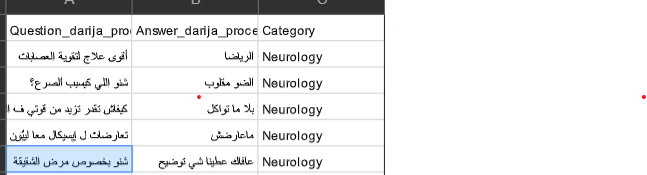

In [ ]:
"""
  - Data Source you can chose any speciality and you can follow this step to fine tuning

"""
# exemple
input_csv = "/content/drive/MyDrive/Colab Notebooks/MedQA-Specialty/Neurology/Neurology_Medicine.csv"
output_jsonl = "/content/drive/MyDrive/Colab Notebooks/Med_MQA/Outputs/Neurology_llama2.jsonl"

# Lire CSV
df = pd.read_csv(input_csv)
df = df.dropna()

question_col = "Question_darija_processesd"
answer_col = "Answer_darija_processesd"

os.makedirs(os.path.dirname(output_jsonl), exist_ok=True)

# Convertir en JSONL
with open(output_jsonl, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        data = {
            "input": str(row[question_col]).strip(),
            "output": str(row[answer_col]).strip()
        }
        f.write(json.dumps(data, ensure_ascii=False) + "\n")

print("Dataset JSONL:", output_jsonl)

## Load Tokenizer and datasets

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("json", data_files=output_jsonl)["train"]

model_name = "meta-llama/Llama-2-13b-chat-hf"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

## Load Model LLama en 4bit using LORA

In [ ]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

import torch

# Charger modèle 4-bit
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype=torch.float16
)

# Config LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Appliquer LoRA
model = get_peft_model(model, lora_config)

## create Data collactor for Training

In [ ]:
from transformers import DataCollatorForSeq2Seq

# Data collator pour causal LM
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    padding=True,
    return_tensors="pt"
)

## Configurer le Trainer

In [ ]:
from transformers import Trainer, TrainingArguments

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Med_MQA/Models/LLaMA2_Darija"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    max_steps=500,
    learning_rate=2e-4,
    fp16=True,
    save_steps=100,
    logging_steps=10,
    save_total_limit=3,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

##Lancer Training

In [ ]:
print("Début du fine-tuning...")
trainer.train()
print("Fine-tuning terminé !")

## Save for Inference

In [ ]:
# Fusionner LoRA + modèle pour inference
model.save_pretrained(f"{OUTPUT_DIR}/final_merged")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/final_merged")
print("Modèle sauvegardé dans :", f"{OUTPUT_DIR}/final_merged")

## Testing

In [ ]:
from transformers import pipeline

# Charger modèle fine-tuné
model_path = f"{OUTPUT_DIR}/final_merged"
inference = pipeline("text-generation", model=model_path, tokenizer=model_path, device=0)

question = "شنو هو علاج الصداع النصفي؟"  # Darija
answer = inference(question, max_length=200, do_sample=True)[0]['generated_text']

print("Q:", question)
print("A:", answer)

     * Essayer de suivre cette etape avec dataset que je vous envoyer.
     * Choisir une specialite Francais ou arabe (Vous pouvez traduire )
     meme 500 exemple bien annoter
     * Apres je vous combiner dataset pour faire une seule data
     * c'est n Terminer comme ca en doit mais dans Hugging Face

In [2]:
# documenter Bien ce que vous ajouter en Markdown
# pull Request vers cette Github https://github.com/Youssef9393/Brain.git